# Avance 1. Análisis exploratorio de datos


Este primer avance consiste en realizar un análisis exploratorio de datos (EDA - Exploratory Data Analysis), es decir, describir los datos utilizando técnicas estadísticas y de visualización (análisis univariante y bi/multivariante) para hacer enfoque en sus aspectos más relevantes, así como aplicar y justificar operaciones de preprocesamiento, relacionadas con el manejo de valores faltantes, atípicos y alta cardinalidad.

## Introducción
### Contexto y Objetivos del Análisis
#### Descripción del problema de negocio o investigación.
En un mundo donde los trastornos mentales afectan a millones de personas, la depresión se ha convertido en una de las principales causas de sufrimiento humano y discapacidad. México no es la excepción: la prevalencia de este padecimiento ha alcanzado niveles críticos, revelando una realidad inquietante. A pesar de la creciente necesidad de atención especializada, persiste una alarmante brecha entre quienes requieren un diagnóstico oportuno y quienes realmente acceden a servicios de salud mental. Esta desconexión no solo compromete la calidad de vida de los individuos, sino que también representa un desafío urgente para los sistemas de salud, tanto a nivel nacional como global. Reconocer esta problemática es el primer paso hacia soluciones efectivas y humanamente necesarias.
Es por esto que se busca el desarrollo de un sistema avanzado de análisis y pronóstico epidemiológico de depresión en México a nivel estatañ y nacional con intervalos de predicción confiables, utilizando modelos de machine learning aplicados a series de tiempo a partir del Boletín Epidemiológico de la Secretaría de Salud, que faciliten la planeación estratégica y la asignación eficiente de recursos en el Sistema Nacional de Salud.
#### Preguntas a responder con el análisis EDA
- ¿Cómo se comporta la serie de tiempo en su estado actual?
- ¿Existen fechas faltantes al comparar la serie con un rango completo de fechas semanales?
- ¿Qué observaciones se consideran atípicas al aplicar ventanas móviles?
- ¿Cómo se distribuyen los datos por mes y por año?
- ¿Qué diferencias se observan en la dispersión mensual o anual mediante boxplots?
- ¿Cómo varía la serie según otras variables relevantes como el estado?
- ¿Cuál es la tendencia subyacente de la serie?d
- ¿La serie cumple con los criterios de estacionaridad según la pru




## Descripción del Conjunto de Datos
#### Origen y descripción de los datos.
Extracción del Boletín Epidemiológico de la Secretaría de Salud. Casos por Entidad Federativa de Enfermedades Neurológicas y de Salud Mental. Codificación: CIE-10 para diagnósticos.
* Depresión CIE-10ª REV.F32
* Enfermedad de Parkinson CIE-10ª REV. G20
* Enfermedad de Alzheimer CIE-10ª REV. G30

Estratificación:
* Sexo (H-M)
* Entidad Federativa  
* Posible inclusión de variables exógenas
* Posible combinación con Cubos Dinámicos.

#### Significado de cada variable.
* Año: año de diagnóstico
* Semana: semana epidemiológica del año de diagnóstico
* Pag.: página en boletín
*	Cuadro: cuadro de diagnóstico
*	No_01: columna vacía
*	Entidad: entidad donde se encuentra caso diagnosticado
* No_02: columna vacía
*	Padecimiento: diagnpostico de enfermedad
*	Ax_001: año de diagnóstico (actual o acumulado)
*	Ax_002: indicativo de valor acumulado
*	Ax_003: indicativo de valor semanal, casos masculinos, femeninos o acumulados
*	No_03: columna vacía
*	Valor: conteo de casos según indicativo
*	No_04: columna vacía

#### Granularidad temporal
221,398 Registros en periodo 2014-2024, con cifras por semana epidemiológica y acumuladas.

### Librerías y Carga de Datos

#### Librerías

In [1]:
import pandas as pd
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

#### Carga de Datos

In [2]:
path = '../../data/raw/data.parquet'
df = pd.read_parquet(path)
df.head()

,Año,Semana,Pag.,Cuadro,No_01,Entidad,No_02,Padecimiento,Ax_001,Ax_002,Ax_003,No_03,Valor,No_04
0,2014,sem02,57,CUADRO 17.,NaN,Aguascalientes,NaN,DepresiónCIE-10ª REV.F32,2014,0,Sem.,NaN,1,NaN
1,2014,sem02,57,CUADRO 17.,NaN,Aguascalientes,NaN,DepresiónCIE-10ª REV.F32,2014,Acum.,H,NaN,1,NaN
2,2014,sem02,57,CUADRO 17.,NaN,Aguascalientes,NaN,DepresiónCIE-10ª REV.F32,2014,Acum.,M,NaN,-,NaN
3,2014,sem02,57,CUADRO 17.,NaN,Aguascalientes,NaN,Enfermedad de Parkinson\nCIE-10ª REV.\nG20,2014,0,Sem.,NaN,-,NaN
4,2014,sem02,57,CUADRO 17.,NaN,Aguascalientes,NaN,Enfermedad de Parkinson\nCIE-10ª REV.\nG20,2014,Acum.,H,NaN,-,NaN


## Limpieza e Inspección Inicial de **Datos**

### Análisis de los Datos

En esta sección realizaremos un análisis exploratorio inicial para entender la estructura y características de nuestro dataset. Examinaremos:

- **Dimensiones del dataset**: Número de filas y columnas

In [3]:
print('Dimensiones del DataFrame:', df.shape)
print(f'Total de registros: {df.shape[0]:,}')
print(f'Total de columnas: {df.shape[1]}')

Dimensiones del DataFrame: (329637, 14)
Total de registros: 329,637
Total de columnas: 14


- **Valores faltantes**: Identificación de datos ausentes por columna

In [4]:
print('\nValores faltantes por columna:')
print(tabulate(df.isnull().sum().reset_index(),
               headers=['Columna', 'Valores faltantes'],
               tablefmt='rounded_outline',
               showindex=False))


Valores faltantes por columna:
╭──────────────┬─────────────────────╮
│ Columna      │   Valores faltantes │
├──────────────┼─────────────────────┤
│ Año          │                   0 │
│ Semana       │                   0 │
│ Pag.         │                   0 │
│ Cuadro       │                   0 │
│ No_01        │              329637 │
│ Entidad      │                   0 │
│ No_02        │              329637 │
│ Padecimiento │                   0 │
│ Ax_001       │                   0 │
│ Ax_002       │                   0 │
│ Ax_003       │                   0 │
│ No_03        │              329637 │
│ Valor        │                   0 │
│ No_04        │              329637 │
╰──────────────┴─────────────────────╯


- **Tipos de datos**: Verificación de tipos de variables (numéricas, categóricas, fechas)

In [5]:
print('\nTipos de datos por columna:')
print(tabulate(df.dtypes.reset_index(),
               headers=['Columna', 'Tipo de dato'],
               tablefmt='rounded_outline',
               showindex=False))


Tipos de datos por columna:
╭──────────────┬────────────────╮
│ Columna      │ Tipo de dato   │
├──────────────┼────────────────┤
│ Año          │ int64          │
│ Semana       │ object         │
│ Pag.         │ int64          │
│ Cuadro       │ object         │
│ No_01        │ float64        │
│ Entidad      │ object         │
│ No_02        │ float64        │
│ Padecimiento │ object         │
│ Ax_001       │ int64          │
│ Ax_002       │ object         │
│ Ax_003       │ object         │
│ No_03        │ float64        │
│ Valor        │ object         │
│ No_04        │ float64        │
╰──────────────┴────────────────╯


- **Valores únicos**: Cardinalidad de cada variable para detectar posibles problemas

In [6]:
print('\nValores únicos por columna:')
print(tabulate(df.nunique().reset_index(),
               headers=['Columna', 'Valores únicos'],
               tablefmt='rounded_outline',
               showindex=False))


Valores únicos por columna:
╭──────────────┬──────────────────╮
│ Columna      │   Valores únicos │
├──────────────┼──────────────────┤
│ Año          │               11 │
│ Semana       │               53 │
│ Pag.         │               26 │
│ Cuadro       │                4 │
│ No_01        │                0 │
│ Entidad      │               34 │
│ No_02        │                0 │
│ Padecimiento │               18 │
│ Ax_001       │               12 │
│ Ax_002       │                3 │
│ Ax_003       │                4 │
│ No_03        │                0 │
│ Valor        │             7740 │
│ No_04        │                0 │
╰──────────────┴──────────────────╯


- **Limpieza inicial**: Renombrado de columnas para mejorar la legibilidad

In [7]:
new_columns = {'Cuadro ': 'Cuadro', 'Entidad': 'Estado'}
df.rename(columns=new_columns, inplace=True)

Este análisis nos permite identificar operaciones de preprocesamiento necesarias antes del análisis más profundo.

### Preprocesamiento

Basándose en el análisis inicial, aplicaremos las siguientes transformaciones a los datos:

**1. Procesamiento de la columna 'Semana'**
- Remover el prefijo 'sem' de los valores
- Convertir a tipo entero para facilitar cálculos temporales

In [8]:
df['Semana'] = df['Semana'].str.replace('sem', '').astype('int')

**2. Creación de columna 'Fecha'**
- Generar fechas utilizando año y semana ISO
- Formato: Año + Semana + día 1 (lunes de cada semana)
- Facilita análisis de series temporales

In [9]:
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + df['Semana'].astype(str) + '1', format='%G%V%u')

**3. Limpieza de la columna 'Valor'**
- Eliminar caracteres no numéricos usando regex
- Convertir a tipo numérico, reemplazando valores inválidos con 0
- Asegurar consistencia en los datos de análisis

In [10]:
# df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce').fillna(0).astype(int)
df['Valor'] = pd.to_numeric(df['Valor'].str.replace(r'[^0-9]', '', regex=True), errors='coerce').fillna(0).astype(int)

**4. Procesamiento de 'Padecimiento'**
- Eliminar saltos de línea que pueden causar problemas
- Extraer códigos de padecimiento (formato REV.X) para análisis

In [11]:
df['Padecimiento'] = df['Padecimiento'].astype(str).str.replace('\n', '')
df['Codigo Padecimiento'] = df['Padecimiento'].str.extract(r'REV\.(.*)')

**5.1 Eliminación de filas innecesarias**
- Remover filas de cualquier padecimiento que no sea depresión
- Para efectos de una mejor calidad en los resultados, únicamente se trabajará con el diagnóstico de depresión

In [12]:
# Elimina todas las filas cuyo código de padecimiento no sea F32
df = df[df['Codigo Padecimiento'] == 'F32']

**5.2 Eliminación de columnas innecesarias**
- Remover columnas que inician con 'No' (columnas vacías)
- Eliminar columna 'Pag.' que no aporta valor analítico

In [13]:
# Eliminar las columnas que tengan el prefijo "No" (Columnas Vacías)
df = df.loc[:, ~df.columns.str.startswith('No')]

# Eliminar la columna Pag. Cuadro, Padecimiento y Codigo Padecimiento
df.drop(columns=['Pag.','Cuadro', 'Ax_002', 'Padecimiento', 'Codigo Padecimiento'], inplace=True)

In [14]:
df.head(5)

,Año,Semana,Estado,Ax_001,Ax_003,Valor,Fecha
0,2014,2,Aguascalientes,2014,Sem.,1,2014-01-06
1,2014,2,Aguascalientes,2014,H,1,2014-01-06
2,2014,2,Aguascalientes,2014,M,0,2014-01-06
9,2014,2,Baja California,2014,Sem.,2,2014-01-06
10,2014,2,Baja California,2014,H,1,2014-01-06


## Inspección Profunda de Datos

En esta sección realizaremos un análisis exhaustivo para detectar y cuantificar datos faltantes en las series temporales del dataset.

### Análisis de Datos de la Serie Completa por Combinación

**1. Detección de combinaciones únicas respecto a las columnas** `Estado` y `Ax_003`

In [15]:
columnas_grupo = ['Estado', 'Ax_003']
combinaciones_unicas = df[columnas_grupo].drop_duplicates()
print(f'Total de combinaciones únicas: {len(combinaciones_unicas):}')
print('Primeras 10 combinaciones únicas:')
print(tabulate(combinaciones_unicas.head(10), headers='keys', tablefmt='rounded_outline',showindex=False))


Total de combinaciones únicas: 136
Primeras 10 combinaciones únicas:
╭─────────────────────┬──────────╮
│ Estado              │ Ax_003   │
├─────────────────────┼──────────┤
│ Aguascalientes      │ Sem.     │
│ Aguascalientes      │ H        │
│ Aguascalientes      │ M        │
│ Baja California     │ Sem.     │
│ Baja California     │ H        │
│ Baja California     │ M        │
│ Baja California Sur │ Sem.     │
│ Baja California Sur │ H        │
│ Baja California Sur │ M        │
│ Campeche            │ Sem.     │
╰─────────────────────┴──────────╯


**2. Definición del rango temporal completo**:
- Rango de fechas desde la fecha mínima hasta la máxima del dataset
- Cantidad de fechas a existir por combinación

In [16]:
fecha_inicial = df['Fecha'].min()
fecha_final = df['Fecha'].max()
fechas_completas = pd.date_range(fecha_inicial, fecha_final, freq="W-MON")
print(f'Rango de fechas: {fecha_inicial.date()} a {fecha_final.date()}')
print(f'Cantidad de fechas únicas a existir en el DataFrame para cada Combinación: {len(fechas_completas)}')

Rango de fechas: 2014-01-06 a 2024-12-23
Cantidad de fechas únicas a existir en el DataFrame para cada Combinación: 573


**3. Detección de valores faltantes por combinación**:



- Cantidad de combinaciones con fechas faltantes

In [17]:
fechas_faltantes_dict = {}

# Agrupar por las combinaciones que te interesan
for keys, grupo in df.groupby(columnas_grupo):
    fechas_existentes = grupo["Fecha"].unique()
    # fechas_completas = pd.date_range(
    #     grupo["Fecha"].min(), grupo["Fecha"].max(), freq="W-MON"
    # )
    fechas_faltantes = fechas_completas.difference(fechas_existentes)
    if len(fechas_faltantes) > 0:
        fechas_faltantes_dict[keys] = fechas_faltantes

# Mostrar resultados
print(f'Total de combinaciones con fechas faltantes: {len(fechas_faltantes_dict):}/{len(combinaciones_unicas):}')


Total de combinaciones con fechas faltantes: 136/136


In [18]:
ncol = 10
print(f'Mostrando las primeras {ncol} combinaciones con fechas faltantes:')

tabla_fechas_faltantes = [
    [
        *combo,
        len(f),
        f"{len(f)*100/len(fechas_completas):.2f}%",
        f
    ]
    for combo, f in list(fechas_faltantes_dict.items())
]
df_fechas_faltantes = pd.DataFrame(
    tabla_fechas_faltantes,
    columns=columnas_grupo + ['Fechas faltantes', '% faltante', 'Listado de fechas faltantes']
)
# Excluye la columnas de Listado de fechas faltantes para mejor visualización
print(tabulate(df_fechas_faltantes.loc[:,df_fechas_faltantes.columns != 'Listado de fechas faltantes'].head(ncol), headers='keys', tablefmt='rounded_outline', showindex=False))

Mostrando las primeras 10 combinaciones con fechas faltantes:
╭─────────────────────┬──────────┬────────────────────┬──────────────╮
│ Estado              │ Ax_003   │   Fechas faltantes │ % faltante   │
├─────────────────────┼──────────┼────────────────────┼──────────────┤
│ Aguascalientes      │ Acum.    │                 54 │ 9.42%        │
│ Aguascalientes      │ H        │                  2 │ 0.35%        │
│ Aguascalientes      │ M        │                  2 │ 0.35%        │
│ Aguascalientes      │ Sem.     │                  2 │ 0.35%        │
│ Baja California     │ Acum.    │                 54 │ 9.42%        │
│ Baja California     │ H        │                  2 │ 0.35%        │
│ Baja California     │ M        │                  2 │ 0.35%        │
│ Baja California     │ Sem.     │                  2 │ 0.35%        │
│ Baja California Sur │ Acum.    │                 54 │ 9.42%        │
│ Baja California Sur │ H        │                  2 │ 0.35%        │
╰──────────────

- Fechas con mayor cantidad de valores Faltantes

In [19]:
# Crear un diccionario para contar cuántas combinaciones faltan en cada fecha
conteo_fechas_faltantes = {}

# Iterar sobre todas las fechas faltantes de cada combinación
for combo, fechas_faltantes in fechas_faltantes_dict.items():
    for fecha in fechas_faltantes:
        if fecha not in conteo_fechas_faltantes:
            conteo_fechas_faltantes[fecha] = 0
        conteo_fechas_faltantes[fecha] += 1

# Convertir a DataFrame y ordenar por cantidad de combinaciones faltantes
df_conteo_fechas = pd.DataFrame([
    [fecha, cantidad]
    for fecha, cantidad in conteo_fechas_faltantes.items()
], columns=['Fecha', 'Combinaciones_faltantes'])

# Ordenar por cantidad de combinaciones faltantes (descendente)
df_conteo_fechas = df_conteo_fechas.sort_values('Combinaciones_faltantes', ascending=False)

print(f'Fechas con mayor cantidad de valores faltantes (Top {ncol}):')
print(tabulate(
    df_conteo_fechas.head(ncol),
    headers='keys',
    tablefmt='rounded_outline',
    showindex=False
))

print(f'\nResumen estadístico:')
print(f'Total de fechas con valores faltantes: {len(df_conteo_fechas)}')
print(f'Fecha con más faltantes: {df_conteo_fechas.iloc[0]["Fecha"].date()} ({df_conteo_fechas.iloc[0]["Combinaciones_faltantes"]} combinaciones)')
print(f'Fecha con menos faltantes: {df_conteo_fechas.iloc[-1]["Fecha"].date()} ({df_conteo_fechas.iloc[-1]["Combinaciones_faltantes"]} combinaciones)')

Fechas con mayor cantidad de valores faltantes (Top 10):
╭─────────────────────┬───────────────────────────╮
│ Fecha               │   Combinaciones_faltantes │
├─────────────────────┼───────────────────────────┤
│ 2015-12-28 00:00:00 │                       136 │
│ 2024-03-04 00:00:00 │                       136 │
│ 2014-01-20 00:00:00 │                        37 │
│ 2014-01-27 00:00:00 │                        37 │
│ 2014-02-03 00:00:00 │                        37 │
│ 2014-02-10 00:00:00 │                        37 │
│ 2014-02-17 00:00:00 │                        37 │
│ 2014-02-24 00:00:00 │                        37 │
│ 2014-03-03 00:00:00 │                        37 │
│ 2014-03-10 00:00:00 │                        37 │
╰─────────────────────┴───────────────────────────╯

Resumen estadístico:
Total de fechas con valores faltantes: 573
Fecha con más faltantes: 2015-12-28 (136 combinaciones)
Fecha con menos faltantes: 2023-08-07 (4 combinaciones)


### Análisis de Datos de la Serie Completa

#### Obtención de la Serie Completa de acuerdo al rango de Fechas establecido

In [20]:
# Todas las combinaciones únicas
# combos = df[columnas_grupo].drop_duplicates()

# Producto cartesiano (todas las combinaciones × todas las semanas)
idx = pd.MultiIndex.from_product(
    [combinaciones_unicas.itertuples(index=False, name=None), fechas_completas],
    names=["Combo", "Fecha"]
)
df_completo = pd.DataFrame(index=idx).reset_index()

# Expandir las columnas del combo
df_completo[columnas_grupo] = pd.DataFrame(
    df_completo["Combo"].tolist(), index=df_completo.index
)

df_completo = df_completo.drop(columns="Combo")

# Unir con tu df original
df_merge = df_completo.merge(
    df, on=["Fecha", "Estado", "Ax_003"], how="left"
)

# Filtrar los registros faltantes
faltantes = df_merge[df_merge.isna().any(axis=1)]

#### Consolidación del Dataset y Enriquecimiento Temporal

Este proceso finaliza la preparación del dataset mediante la integración de información de referencia y la creación de variables temporales adicionales para facilitar el análisis de series de tiempo.



**1. Creación de tabla de referencia de Padecimientos e Integracion de datos:**

- Extracción de códigos y nombres únicos de padecimientos
- Eliminación de duplicados para crear un catálogo limpio
- Merge entre el dataset expandido (`df_merge`) y la tabla de referencia
- Recuperación de nombres completos de padecimientos para registros con datos faltantes
    - Uso de `right join` para preservar todos los códigos de padecimiento

**2. Enriquecimiento temporal:**

- Generación de variables Año y Semana a partir de fechas ISO
- Facilitación de análisis por períodos temporales específicos

In [21]:
df_merge["Año"] = df_merge["Fecha"].dt.isocalendar().year
df_merge["Semana"] = df_merge["Fecha"].dt.isocalendar().week

In [22]:
df_final = df_merge.copy()
df_final.head()

,Fecha,Estado,Ax_003,Año,Semana,Ax_001,Valor
0,2014-01-06,Aguascalientes,Sem.,2014,2,2014.0,1.0
1,2014-01-13,Aguascalientes,Sem.,2014,3,2014.0,2.0
2,2014-01-20,Aguascalientes,Sem.,2014,4,2014.0,1.0
3,2014-01-27,Aguascalientes,Sem.,2014,5,2014.0,1.0
4,2014-02-03,Aguascalientes,Sem.,2014,6,2014.0,2.0


#### Análisis

En esta sección realizaremos un análisis exploratorio para entender la estructura y características de nuestro dataset. Examinaremos:

- **Dimensiones del dataset**: Número de filas y columnas

In [23]:
print('Dimensiones del DataFrame:', df_final.shape)
print(f'Total de registros: {df_final.shape[0]:,}')
print(f'Total de columnas: {df_final.shape[1]}')

Dimensiones del DataFrame: (78027, 7)
Total de registros: 78,027
Total de columnas: 7


- **Valores faltantes**: Identificación de datos ausentes por columna

In [24]:
print('\nValores faltantes por columna:')
print(tabulate(df_final.isnull().sum().reset_index(),
               headers=['Columna', 'Valores faltantes'],
               tablefmt='rounded_outline',
               showindex=False))


Valores faltantes por columna:
╭───────────┬─────────────────────╮
│ Columna   │   Valores faltantes │
├───────────┼─────────────────────┤
│ Fecha     │                   0 │
│ Estado    │                   0 │
│ Ax_003    │                   0 │
│ Año       │                   0 │
│ Semana    │                   0 │
│ Ax_001    │                4272 │
│ Valor     │                4272 │
╰───────────┴─────────────────────╯


- **Tipos de datos**: Verificación de tipos de variables (numéricas, categóricas, fechas)

In [25]:
print('\nTipos de datos por columna:')
print(tabulate(df_final.dtypes.reset_index(),
               headers=['Columna', 'Tipo de dato'],
               tablefmt='rounded_outline',
               showindex=False))


Tipos de datos por columna:
╭───────────┬────────────────╮
│ Columna   │ Tipo de dato   │
├───────────┼────────────────┤
│ Fecha     │ datetime64[ns] │
│ Estado    │ object         │
│ Ax_003    │ object         │
│ Año       │ UInt32         │
│ Semana    │ UInt32         │
│ Ax_001    │ float64        │
│ Valor     │ float64        │
╰───────────┴────────────────╯


- **Valores únicos**: Cardinalidad de cada variable para detectar posibles problemas

In [26]:
print('\nValores únicos por columna:')
print(tabulate(df_final.nunique().reset_index(),
               headers=['Columna', 'Valores únicos'],
               tablefmt='rounded_outline',
               showindex=False))


Valores únicos por columna:
╭───────────┬──────────────────╮
│ Columna   │   Valores únicos │
├───────────┼──────────────────┤
│ Fecha     │              573 │
│ Estado    │               34 │
│ Ax_003    │                4 │
│ Año       │               11 │
│ Semana    │               53 │
│ Ax_001    │               11 │
│ Valor     │             7521 │
╰───────────┴──────────────────╯


In [27]:
# Guarda el df_final en un archivo .parquet
# df_final.to_parquet('../../data/processed/data3.parquet', index=False)
# print(f'DataFrame guardado exitosamente con {len(df_final):,} registros')
# print(f'Archivo guardado en: ../../data/processed/data3.parquet')

## Análisis Visual de la Serie Temporal

### Gráfico General de la Serie Temporal

#### Datos Completos

In [28]:
filtro_base = (df['Estado']=='TOTAL') \
          & ((df['Ax_003']=='H') | (df['Ax_003']=='M'))
df_general_base = df[filtro_base]

df_acumulado_base = df_general_base.groupby('Fecha')['Valor'].sum().reset_index()
# Calcula la suma acumulada para evitar reinicios anuales
df_acumulado_base['Valor_acumulado'] = df_acumulado_base['Valor'].cumsum()
df_acumulado_base['Semana'] = df_acumulado_base['Fecha'].dt.isocalendar().week
display(df_acumulado_base.head())

,Fecha,Valor,Valor_acumulado,Semana
0,2014-01-06,131,131,2
1,2014-01-13,790,921,3
2,2014-01-20,1726,2647,4
3,2014-01-27,2761,5408,5
4,2014-02-03,3985,9393,6


In [29]:
filtro_general = (df_final['Estado']=='TOTAL') \
          & ((df_final['Ax_003']=='H') | (df_final['Ax_003']=='M'))
df_general = df_final[filtro_general]

In [30]:
def acumulado(df):
    df_acumulado = df.groupby('Fecha')['Valor'].sum().reset_index()
    df_acumulado['Valor_acumulado'] = df_acumulado['Valor'].cumsum()
    df_acumulado['Semana'] = df_acumulado['Fecha'].dt.isocalendar().week
    return df_acumulado

In [31]:
df_acumulado =acumulado(df_general)
df_acumulado.head()

,Fecha,Valor,Valor_acumulado,Semana
0,2014-01-06,131.0,131.0,2
1,2014-01-13,790.0,921.0,3
2,2014-01-20,1726.0,2647.0,4
3,2014-01-27,2761.0,5408.0,5
4,2014-02-03,3985.0,9393.0,6


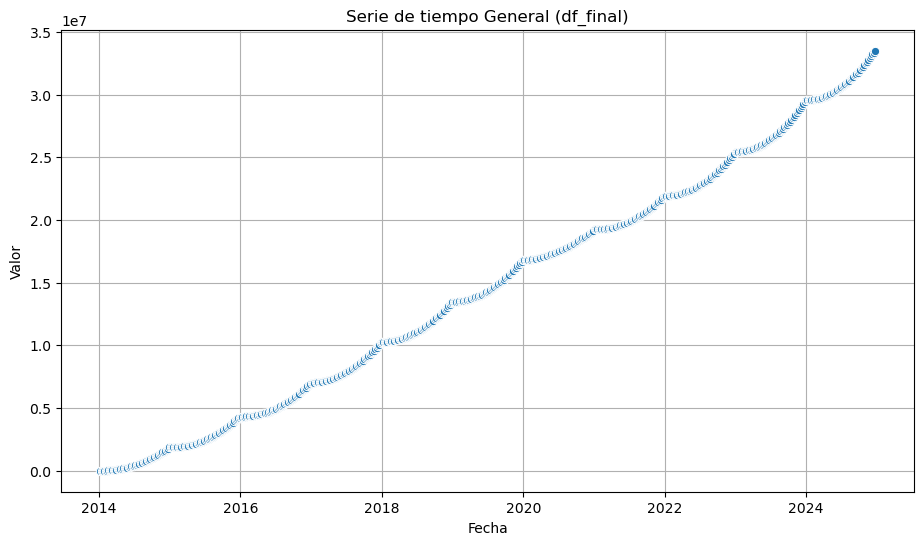

In [32]:
# Gráfica de línea con seaborn
fig = sns.lineplot(data=df_acumulado, x='Fecha', y='Valor_acumulado', marker='o')
fig.set_title('Serie de tiempo General (df_final)')
fig.set_xlabel('Fecha')
fig.set_ylabel('Valor')
fig.grid(True)
fig.figure.set_size_inches(11, 6)
plt.show()

# Gráfica de línea con plotly
fig = px.line(df_acumulado, x='Fecha', y='Valor_acumulado',title=f"Serie de tiempo General (df_final)",
              hover_data={'Semana': True, 'Fecha': True},
              markers=True,
            )
# Ajustar el tamaño de los marcadores
fig.update_traces(marker=dict(size=4))
# # fig.update_layout(height=800)
fig.show()

#### Datos Base

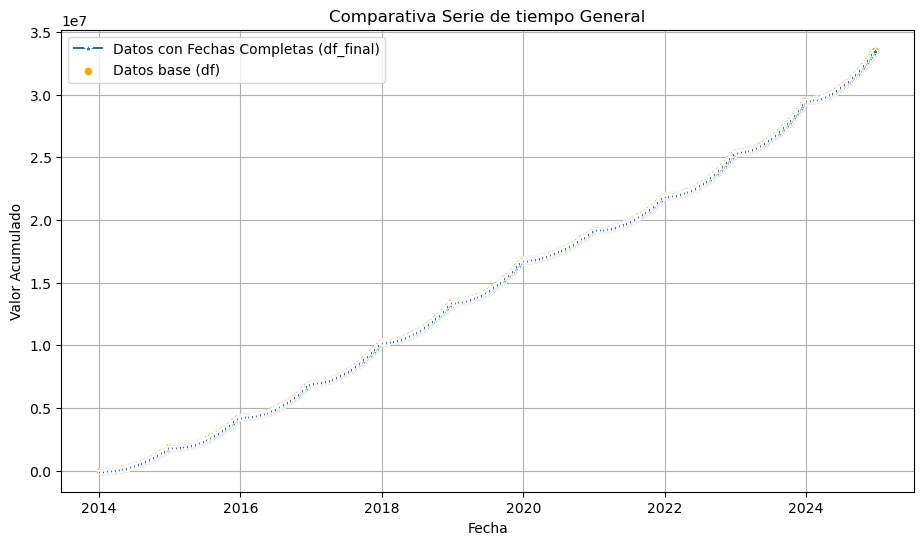

In [33]:
# Gráfica de línea con seaborn  - Comparativa entre df_final y df (base)
fig = sns.lineplot(data=df_acumulado, x='Fecha', y='Valor_acumulado', marker='*', label='Datos con Fechas Completas (df_final)')
fig = sns.scatterplot(data=df_acumulado_base, x='Fecha', y='Valor_acumulado', color='orange', label='Datos base (df)')
fig.set_title('Comparativa Serie de tiempo General')
fig.set_xlabel('Fecha')
fig.set_ylabel('Valor Acumulado')
fig.legend()
fig.grid(True)
fig.figure.set_size_inches(11, 6)
plt.show()

# Gráfica de línea con plotly - Comparativa entre df_final y df (base)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x = df_acumulado['Fecha'],
    y= df_acumulado['Valor_acumulado'],
    name= 'Datos con Fechas Completas',
    mode='lines+markers',
    customdata=df_acumulado['Semana'],
    hovertemplate=(
        '<b>Fecha</b>: %{x}<br>' +
        '<b>Valor Acumulado</b>: %{y}<br>' +
        '<b>Semana</b>: %{customdata}<br>' + # Accede a la primera columna de customdata
        '<extra></extra>' # Oculta la información secundaria del trace
    )
))
fig.add_trace(go.Scatter(
    x = df_acumulado_base['Fecha'],
    y= df_acumulado_base['Valor_acumulado'],
    name= 'Datos base',
    mode='markers',
    customdata=df_acumulado_base['Semana'],
    hovertemplate=(
        '<b>Fecha</b>: %{x}<br>' +
        '<b>Valor Acumulado</b>: %{y}<br>' +
        '<b>Semana</b>: %{customdata}<br>' + # Accede a la primera columna de customdata
        '<extra></extra>' # Oculta la información secundaria del trace
    )
))
fig.update_traces(marker=dict(size=4))
fig.show()


In [34]:
filtros = (df_final['Estado']=='TOTAL') \
          & (df_final['Ax_003'] == 'Sem.')
df_general = df_final.loc[filtros].copy()

# Calcula la suma acumulada para evitar reinicios anuales
df_general['Valor_acumulado'] = df_general['Valor'].cumsum()

df_general.head()

,Fecha,Estado,Ax_003,Año,Semana,Ax_001,Valor,Valor_acumulado
55104,2014-01-06,TOTAL,Sem.,2014,2,2014.0,131.0,131.0
55105,2014-01-13,TOTAL,Sem.,2014,3,2014.0,658.0,789.0
55106,2014-01-20,TOTAL,Sem.,2014,4,2014.0,933.0,1722.0
55107,2014-01-27,TOTAL,Sem.,2014,5,2014.0,1023.0,2745.0
55108,2014-02-03,TOTAL,Sem.,2014,6,2014.0,1151.0,3896.0


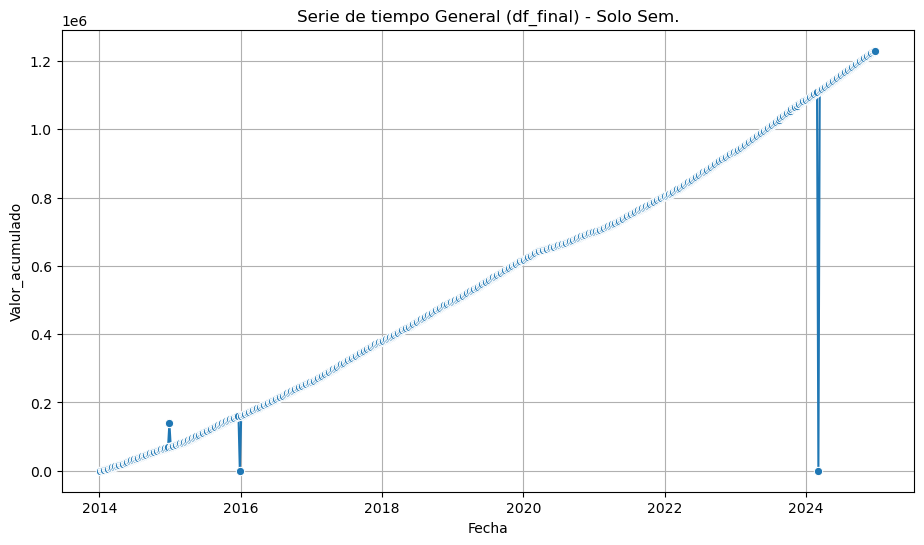

In [35]:
df_acumulado = df_general.groupby('Fecha')['Valor_acumulado'].sum().reset_index()
df_acumulado['Semana'] = df_acumulado["Fecha"].dt.isocalendar().week
# display(df_acumulado.head())

# Gráfica de línea con seaborn
fig = sns.lineplot(data=df_acumulado, x='Fecha', y='Valor_acumulado', marker='o')
fig.set_title('Serie de tiempo General (df_final) - Solo Sem.')
fig.grid(True)
fig.figure.set_size_inches(11, 6)
plt.show()
plt.show()

# # Gráfica de línea con plotly
fig = px.line(df_acumulado, x='Fecha', y='Valor_acumulado',title=f"Serie de tiempo General (df)",
              hover_data={'Semana': True, 'Fecha': True},
              markers=True,
            )
# Ajustar el tamaño de los marcadores
fig.update_traces(marker=dict(size=4))
# # fig.update_layout(height=800)
fig.show()

In [36]:
print('Primeras 10 filas del DataFrame acumulado:')
print(tabulate(df_acumulado[:10],headers='keys',tablefmt='rounded_outline',showindex=True))

Primeras 10 filas del DataFrame acumulado:
╭────┬─────────────────────┬───────────────────┬──────────╮
│    │ Fecha               │   Valor_acumulado │   Semana │
├────┼─────────────────────┼───────────────────┼──────────┤
│  0 │ 2014-01-06 00:00:00 │               131 │        2 │
│  1 │ 2014-01-13 00:00:00 │               789 │        3 │
│  2 │ 2014-01-20 00:00:00 │              1722 │        4 │
│  3 │ 2014-01-27 00:00:00 │              2745 │        5 │
│  4 │ 2014-02-03 00:00:00 │              3896 │        6 │
│  5 │ 2014-02-10 00:00:00 │              4823 │        7 │
│  6 │ 2014-02-17 00:00:00 │              6141 │        8 │
│  7 │ 2014-02-24 00:00:00 │              7400 │        9 │
│  8 │ 2014-03-03 00:00:00 │              8798 │       10 │
│  9 │ 2014-03-10 00:00:00 │             10098 │       11 │
╰────┴─────────────────────┴───────────────────┴──────────╯


## Valores atípicos

### Definición del tamaño de la ventana móvil

El tamaño de la ventana móvil es un parámetro crucial. Un tamaño de ventana más pequeño capturará fluctuaciones más rápidas, mientras que un tamaño más grande suavizará la serie y detectará desviaciones más grandes. Para datos semanales, una ventana de 4 semanas podría ser un buen punto de partida para capturar tendencias mensuales.

In [37]:
# Definir el tamaño de la ventana móvil (en número de semanas)
window_size = 4
print(f"Tamaño de la ventana móvil definido como: {window_size} semanas")

Tamaño de la ventana móvil definido como: 4 semanas


Se calcula la media móvil y la desviación estándar móvil para la serie temporal de casos de depresión utilizando el tamaño de ventana definido. Estas estadísticas ayudan a identificar valores que se desvían significativamente de la norma local.

In [38]:
# Calcular la media móvil y la desviación estándar móvil
df_acumulado['Rolling_Mean'] = df_acumulado['Valor_acumulado'].rolling(window=window_size, min_periods=window_size -1).mean()
df_acumulado['Rolling_Std'] = df_acumulado['Valor_acumulado'].rolling(window=window_size, min_periods=window_size-1).std()

# Mostrar las primeras filas con las nuevas columnas
print("DataFrame con media móvil y desviación estándar móvil:")
display(df_acumulado.head())

DataFrame con media móvil y desviación estándar móvil:


,Fecha,Valor_acumulado,Semana,Rolling_Mean,Rolling_Std
0,2014-01-06,131.0,2,NaN,NaN
1,2014-01-13,789.0,3,NaN,NaN
2,2014-01-20,1722.0,4,880.666667,799.451270
3,2014-01-27,2745.0,5,1346.750000,1137.987807
4,2014-02-03,3896.0,6,2288.000000,1336.895658


Se define un umbral para identificar los valores que se desvían significativamente de la media móvil. Un enfoque común es usar un múltiplo de la desviación estándar (por ejemplo, 2 o 3 desviaciones estándar). En este caso se utilizan 1.4

In [39]:
# Definir el umbral para la detección de valores atípicos (número de desviaciones estándar)
threshold = 1.4

# Calcular los límites superior e inferior para la detección de valores atípicos
df_acumulado['Upper_Bound'] = df_acumulado['Rolling_Mean'] + (df_acumulado['Rolling_Std'] * threshold)
df_acumulado['Lower_Bound'] = df_acumulado['Rolling_Mean'] - (df_acumulado['Rolling_Std'] * threshold)

# Identificar los valores atípicos
df_acumulado['Is_Outlier'] = (df_acumulado['Valor_acumulado'] > df_acumulado['Upper_Bound']) | (df_acumulado['Valor_acumulado'] < df_acumulado['Lower_Bound'])

# Filtrar para mostrar solo los valores atípicos
outliers = df_acumulado[df_acumulado['Is_Outlier']]

print(f"Valores atípicos identificados (usando un umbral de {threshold} desviaciones estándar): ({len(outliers)})")
display(outliers)

Valores atípicos identificados (usando un umbral de 1.4 desviaciones estándar): (3)


,Fecha,Valor_acumulado,Semana,Rolling_Mean,Rolling_Std,Upper_Bound,Lower_Bound,Is_Outlier
51,2014-12-29,138391.0,1,85113.5,35528.203712,1.348530e+05,35374.014803,True
103,2015-12-28,0.0,53,119102.0,79408.165575,2.302734e+05,7930.568195,True
530,2024-03-04,0.0,10,829568.5,553051.746395,1.603841e+06,55296.055046,True


### Visualización de valores atípicos

Se grafica la serie temporal original junto con los valores atípicos identificados para visualizar su ubicación y magnitud.

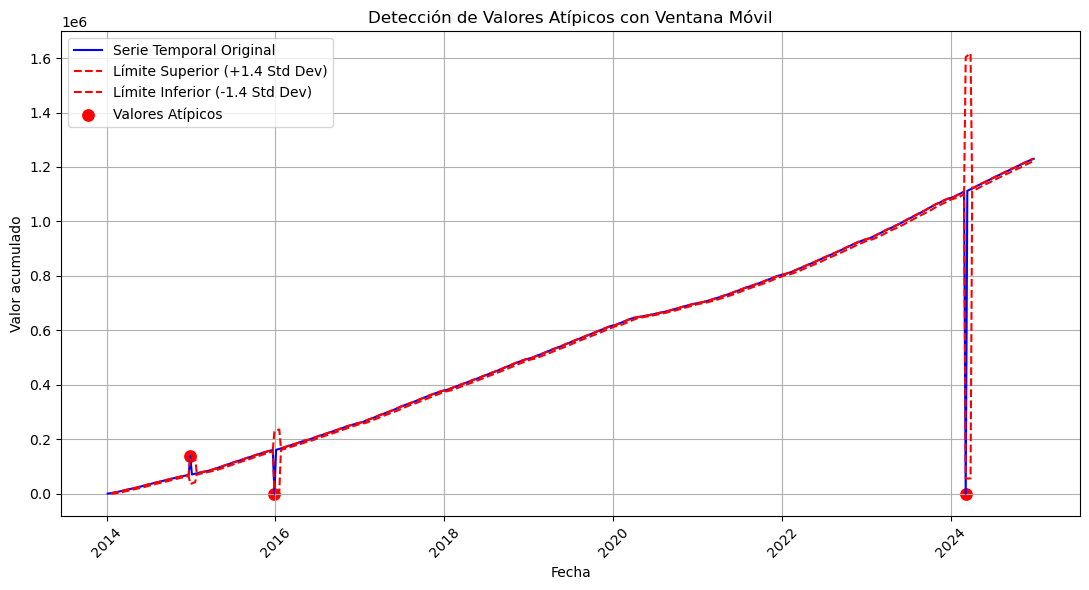

In [40]:
# Graficar la serie temporal original junto con los límites y los valores atípicos con seaborn
plt.figure(figsize=(11, 6))

# Graficar la serie temporal original
sns.lineplot(data=df_acumulado, x='Fecha', y='Valor_acumulado', label='Serie Temporal Original', color='blue')

# Graficar los límites superior e inferior
sns.lineplot(data=df_acumulado, x='Fecha', y='Upper_Bound', label=f'Límite Superior (+{threshold} Std Dev)', color='red', linestyle='--')
sns.lineplot(data=df_acumulado, x='Fecha', y='Lower_Bound', label=f'Límite Inferior (-{threshold} Std Dev)', color='red', linestyle='--')

# Resaltar los valores atípicos
sns.scatterplot(data=outliers, x='Fecha', y='Valor_acumulado', label='Valores Atípicos', color='red', s=100)

# Configurar el título y las etiquetas
plt.title('Detección de Valores Atípicos con Ventana Móvil')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
# Mostrar el gráfico
plt.show()

# # Graficar la serie temporal original junto con los límites y los valores atípicos con Plotly
fig = go.Figure()

# Agregar la serie temporal original
fig.add_trace(go.Scattergl(
    x=df_acumulado['Fecha'],
    y=df_acumulado['Valor_acumulado'],
    mode='lines',
    name='Serie Temporal Original',
    line=dict(color='blue', width=1)
))

# Agregar los límites superior e inferior
fig.add_trace(go.Scattergl(
    x=df_acumulado['Fecha'],
    y=df_acumulado['Upper_Bound'],
    mode='lines',
    name=f'Límite Superior (+{threshold} Std Dev)',
    line=dict(color='red', dash='dot', width=1),
    opacity=0.7
))

fig.add_trace(go.Scattergl(
    x=df_acumulado['Fecha'],
    y=df_acumulado['Lower_Bound'],
    mode='lines',
    name=f'Límite Inferior (-{threshold} Std Dev)',
    line=dict(color='red', dash='dot', width=1),
    opacity=0.7
))

# Resaltar los valores atípicos
fig.add_trace(go.Scattergl(
    x=outliers['Fecha'],
    y=outliers['Valor_acumulado'],
    mode='markers',
    name='Valores Atípicos',
    marker=dict(color='red', size=8, symbol='circle')
))

# Configurar el layout del gráfico
fig.update_layout(
    title='Detección de Valores Atípicos con Ventana Móvil',
    xaxis_title='Fecha',
    yaxis_title='Valor Acumulado',
    hovermode='x unified'
)

# Mostrar el gráfico
fig.show()

### Análisis de Valores Atípicos

De acuerdo con la gráfico obtenida, se puede confirmar que la serie temporal de casos de depresión exhibe un comportamiento excepcionalmente estable a lo largo de diez años, pero con **dos anomalías críticas** al final del registro.

#### **Estabilidad de la Tendencia (Comportamiento "Normal")**

* La línea azul (Serie Original) muestra una **fuerte y consistente tendencia de crecimiento** desde 2014.
* La inmensa mayoría de los puntos (los círculos rojos que forman la línea) **se encuentran dentro de los límites** definidos por la ventana móvil.
* **Conclusión:** Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### **Anomalías Críticas**

El análisis identifica dos puntos que rompen drásticamente el patrón, sugiriendo fallos en el proceso de reporte o registro:

* **Pico Atípico Positivo (2015):** Hay un punto atípico cerca de 2015. Este es un **salto acumulado** inusualmente alto, que podría indicar una corrección de datos o un registro masivo de casos pendientes.
* **Valle Atípico Negativo (Finales de 2024):** El punto más preocupante es el **último valor**, donde la serie cae de manera abrupta casi a cero. Dado que es una serie acumulada, una caída tan severa solo puede deberse a un **error de registro** o una **interrupción total del sistema de reporte**. Este punto no es un valor atípico "natural," sino una clara anomalía técnica.

En resumen, la serie de tiempo está dominada por una **tendencia robusta**. Los modelos predictivos funcionarán bien siempre y cuando se **corrijan los dos valores atípicos** (el pico de 2015 y la caída final de 2024) para evitar que distorsionen el entrenamiento del modelo.

* Se corrigen los valores atípicos interpolando:

In [41]:
# Copia la serie original
serie_corregida = df_acumulado['Valor_acumulado'].copy()

# Reemplaza los outliers por NaN
serie_corregida[df_acumulado['Is_Outlier']] = np.nan

# Interpola los valores NaN (outliers) usando método lineal
serie_corregida = serie_corregida.interpolate(method='linear')

# Actualizar el DataFrame original
df_acumulado['Valor_acumulado_corregido'] = serie_corregida

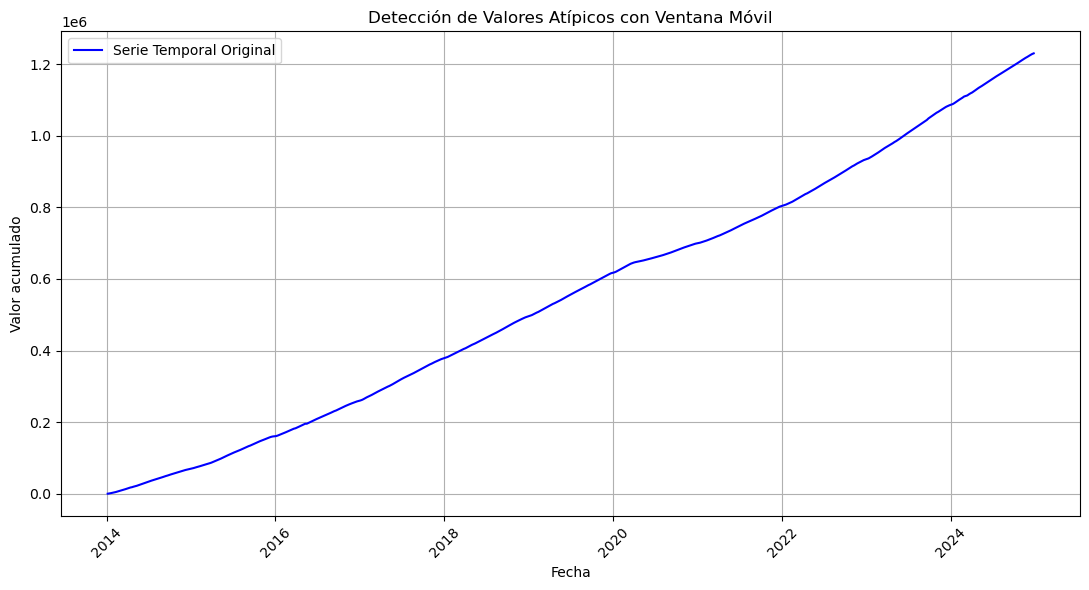

In [42]:
# Graficar la serie temporal original junto con los límites y los valores atípicos con seaborn
plt.figure(figsize=(11, 6))

# Graficar la serie temporal original
sns.lineplot(data=df_acumulado, x='Fecha', y='Valor_acumulado_corregido', label='Serie Temporal Original', color='blue')

# Configurar el título y las etiquetas
plt.title('Detección de Valores Atípicos con Ventana Móvil')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
# Mostrar el gráfico
plt.show()

# # Graficar la serie temporal original junto con los límites y los valores atípicos con Plotly
fig = go.Figure()

# Agregar la serie temporal original
fig.add_trace(go.Scattergl(
    x=df_acumulado['Fecha'],
    y=df_acumulado['Valor_acumulado_corregido'],
    mode='lines',
    name='Serie Temporal Original',
    line=dict(color='blue', width=1)
))

# Configurar el layout del gráfico
fig.update_layout(
    title='Detección de Valores Atípicos con Ventana Móvil',
    xaxis_title='Fecha',
    yaxis_title='Valor Acumulado',
    hovermode='x unified'
)

# Mostrar el gráfico
fig.show()

## Agrupaciones por período de tiempo (boxplots)

Para facilitar el análisis por períodos, extraeremos el mes y el año de la columna 'Fecha' y crearemos nuevas columnas en el DataFrame.

In [43]:
# Extraer el mes de la columna 'Fecha'
df_acumulado['Mes'] = df_acumulado['Fecha'].dt.month
df_acumulado['Año'] = df_acumulado['Fecha'].dt.year

# Mostrar las primeras filas con la nueva columna
print("DataFrame con columnas 'Mes' y 'Año' añadidas:")
display(df_acumulado.head())

DataFrame con columnas 'Mes' y 'Año' añadidas:


,Fecha,Valor_acumulado,Semana,Rolling_Mean,Rolling_Std,Upper_Bound,Lower_Bound,Is_Outlier,Valor_acumulado_corregido,Mes,Año
0,2014-01-06,131.0,2,NaN,NaN,NaN,NaN,False,131.0,1,2014
1,2014-01-13,789.0,3,NaN,NaN,NaN,NaN,False,789.0,1,2014
2,2014-01-20,1722.0,4,880.666667,799.451270,1999.898445,-238.565112,False,1722.0,1,2014
3,2014-01-27,2745.0,5,1346.750000,1137.987807,2939.932930,-246.432930,False,2745.0,1,2014
4,2014-02-03,3896.0,6,2288.000000,1336.895658,4159.653921,416.346079,False,3896.0,2,2014


Se agrupa el DataFrame por mes. 
Se crean boxplots para visualizar la distribución de los valores en cada mes. 
Esto ayuda a entender la variabilidad mensual y a identificar posibles patrones estacionales.

Estadísticas descriptivas por mes:


,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,49.0,523876.693878,350813.366440,131.0,260362.0,501251.0,807565.0,1097291.0
2,45.0,505483.533333,350378.964716,3896.0,173646.0,507830.0,813724.0,1109313.0
3,48.0,508970.541667,351998.891950,8798.0,181209.0,519067.5,745855.5,1118319.0
4,47.0,541408.787234,353057.398975,15885.0,240933.0,530171.0,835565.0,1133475.0
5,49.0,548172.489796,351465.774781,20927.0,200019.0,541195.0,846490.0,1144880.0
6,47.0,532560.106383,358950.091110,27073.0,205457.5,548970.0,802285.0,1156961.0
7,49.0,575072.857143,357813.736753,35075.0,321619.0,561321.0,870676.0,1171397.0
8,49.0,566525.612245,354358.423682,40584.0,224323.0,572978.0,878453.0,1182853.0
9,47.0,582037.638298,369093.914120,46542.0,233473.0,582740.0,893377.0,1196995.0


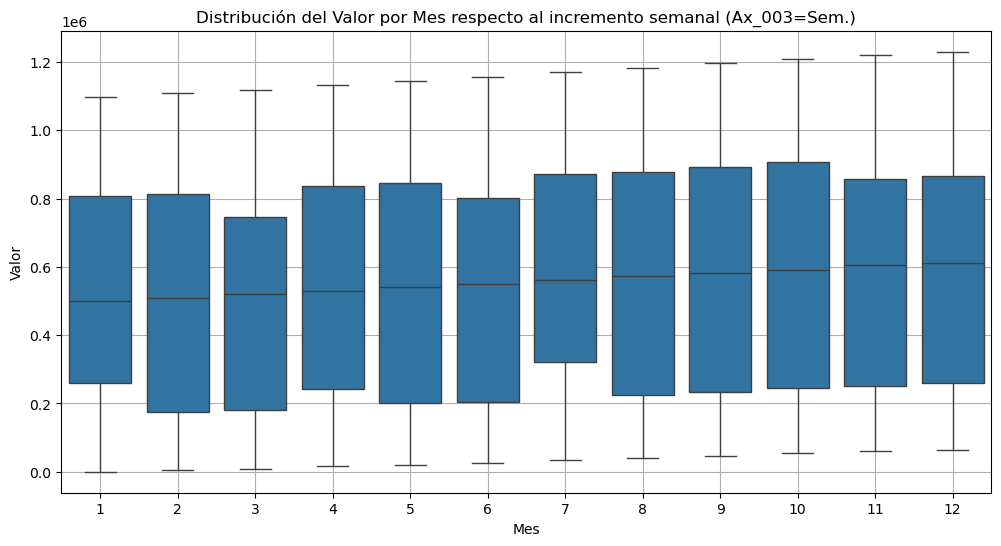

In [44]:
# df_filtrado = df_final[(df_final['Estado']!='TOTAL') & ((df_final['Ax_003']=='H') | (df_final['Ax_003']=='M'))] 
# df_filtrado = df_final[(df_final['Estado']=='TOTAL') & ((df_final['Ax_003']=='Sem.') )]

# Agrupar por mes y calcular estadísticas descriptivas
monthly_stats = df_acumulado.groupby(['Mes'])['Valor_acumulado_corregido'].describe()
print("Estadísticas descriptivas por mes:")
display(monthly_stats)

# Crear un boxplot interactivo para visualizar la distribución por mes con seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_acumulado, x='Mes', y='Valor_acumulado_corregido')
plt.title(f'Distribución del Valor por Mes respecto al incremento semanal (Ax_003=Sem.)')
plt.xlabel('Mes')
plt.ylabel('Valor')
plt.grid(True)
plt.show()
# # Crear un boxplot interactivo para visualizar la distribución por mes con plotly
fig = px.box(df_acumulado, x='Mes', y='Valor_acumulado_corregido',
             title='Distribución del Valor por Mes',
             labels={'Mes': 'Mes', 'Valor_acumulado_corregido': 'Valor'},
             hover_data={'Semana': True,},
             category_orders={"Mes": sorted(df_acumulado['Mes'].unique())}) # Asegurar el orden correcto de los meses

fig.update_layout(xaxis = dict(tickmode = 'linear', tick0 = 1, dtick = 1)) # Asegurar que se muestren todos los meses
fig.show()

### **Análisis de la Distribución Mensual (Incremento Semanal Agregado)**

* **Ausencia de Estacionalidad Fuerte:** No existe una tendencia clara o un crecimiento significativo en el número promedio de casos semanales entre los meses 1 (enero) y 12 (diciembre). Las medianas (la línea dentro de cada caja) se mantienen en un rango estrecho, alrededor de **500,000**, lo que indica que, en promedio, el volumen de casos reportados semanalmente es bastante **uniforme** a lo largo del año.
* **Distribución Simétrica:** A diferencia de las distribuciones sesgadas de los análisis de valores totales, estas cajas son más **simétricas**, con las medianas cerca del centro de la caja. Esto sugiere que, una vez que se agrupan los incrementos semanales, la mayoría de las observaciones mensuales se concentran cerca del valor central.
* **Variabilidad Constante:** El tamaño de las cajas y la extensión de los bigotes son relativamente constantes en todos los meses. Esto significa que la variabilidad en el reporte de casos semanales no cambia drásticamente con la temporada, lo que refuerza la idea de una **serie de tiempo estable** una vez que se elimina el ruido de la estacionalidad de los valores totales.
* **Picos y Valles:** Aunque el gráfico no muestra los *outliers* individuales con la misma claridad que antes, los límites superior e inferior (los bigotes) se extienden a valores altos y bajos similares en todos los meses.

### Agrupación por año

Ahora se agrupa el DataFrame por año, se visualiza igualmente por medio de boxplots la distribución de los valores en cada año. Esto ayuda a entender la variabilidad anual y a identificar posibles tendencias a lo largo del tiempo.


Estadísticas descriptivas por año:


,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,52.0,3.418182e+04,21656.023640,131.0,15509.75,34339.5,52906.50,69426.5
2015,52.0,1.144089e+05,28558.059819,70482.0,88198.75,114203.0,139034.75,160504.0
2016,52.0,2.099387e+05,29832.771184,161012.0,184324.00,209520.5,235102.00,259142.0
2017,52.0,3.195100e+05,35529.789125,260362.0,289801.75,320334.0,349446.25,377331.0
2018,53.0,4.368803e+05,35708.166409,378684.0,406309.00,436513.0,467368.00,495394.0
2019,52.0,5.573642e+05,36305.064449,496810.0,527073.50,557604.5,587925.00,617020.0
2020,52.0,6.613770e+05,22573.613081,618274.0,646545.00,660563.0,679341.50,699241.0
2021,52.0,7.489302e+05,31604.390646,700050.0,721034.50,748532.0,774744.25,803070.0
2022,52.0,8.673248e+05,39750.591251,804278.0,833537.00,866897.5,900700.25,933376.0


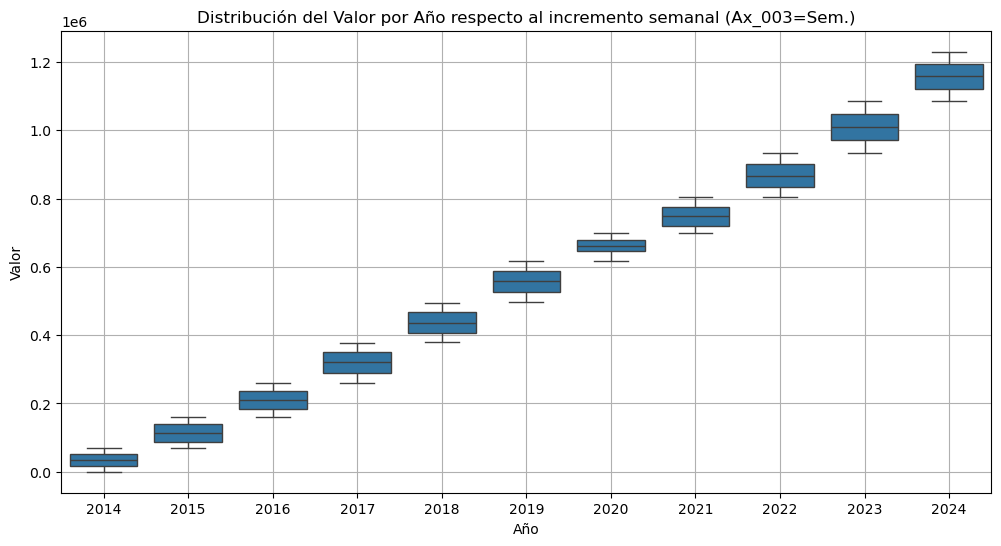

In [45]:
yearly_stats = df_acumulado.groupby(['Año'])['Valor_acumulado_corregido'].describe()
print("\nEstadísticas descriptivas por año:")
display(yearly_stats)

# Crear un boxplot interactivo para visualizar la distribución por año con seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_acumulado, x='Año', y='Valor_acumulado_corregido')
plt.title(f'Distribución del Valor por Año respecto al incremento semanal (Ax_003=Sem.)')
plt.xlabel('Año')
plt.ylabel('Valor')
plt.grid(True)
plt.show()
# Crear un boxplot interactivo con Plotly para visualizar la distribución por año
fig = px.box(df_acumulado, x='Año', y='Valor_acumulado_corregido',
             title='Distribución del Valor por Año',
             labels={'Año': 'Año', 'Valor_acumulado_corregido': 'Valor'},
             hover_data={'Semana': True,},
             category_orders={"Año": sorted(df_final['Año'].unique())}) # Asegurar el orden correcto de los años

fig.update_layout(xaxis = dict(tickmode = 'linear', dtick = 1)) # Asegurar que se muestren todos los años
fig.show()

### **Análisis de la Distribución Anual**

Este gráfico es fundamental porque, a diferencia del análisis de los incrementos semanales individuales, muestra la **distribución total de los casos reportados semanalmente a lo largo de los años**.

* **Tendencia Creciente Imparable:** El patrón dominante es una **tendencia de crecimiento lineal y muy fuerte**. Cada caja de un año es notablemente más alta que la del año anterior, sin ninguna interrupción significativa (ni siquiera el año 2020 muestra una caída). Esto significa que la **cantidad total de casos reportados por incremento semanal ha aumentado constantemente** y sin pausa de 2014 a 2024. 
* **Estabilidad y Uniformidad:** Las cajas son notablemente uniformes en su forma y tamaño a lo largo de los años.
    * **Distribución Centrada:** Las medianas (líneas en el centro de las cajas) son consistentes con el crecimiento y se encuentran cerca del centro de cada caja.
    * **Variabilidad Constante:** El rango intercuartílico (la altura de la caja) y la extensión de los bigotes son similares. Esto indica que la **variabilidad** en el volumen semanal de casos no ha cambiado drásticamente; simplemente, todo el rango de valores se ha desplazado hacia arriba.

* **Sin Asimetría o Atípicos Evidentes:** A diferencia de otros análisis, esta agregación por año muestra una distribución muy **simétrica** y no presenta los valores atípicos extremos por encima o por debajo de los bigotes. Esto se debe a que la **fuerza de la tendencia es tan grande** que las fluctuaciones semanales se vuelven insignificantes a escala anual.

In [46]:
# Guarda el df_acumulado en un archivo .parquet
# df_acumulado.to_parquet('../../data/processed/df_acumulado.parquet', index=False)
# print(f'DataFrame guardado exitosamente con {len(df_acumulado):,} registros')
# print(f'Archivo guardado en: ../../data/processed/df_acumulado.parquet')

## Análisis de género

In [47]:
# Filtrar datos para hombres y mujeres
filtro_h = (df['Estado']=='TOTAL') & ((df['Ax_003']=='H'))
filtro_m = (df['Estado']=='TOTAL') & ((df['Ax_003']=='M'))
df_h = df[filtro_h]
df_m = df[filtro_m]

In [48]:
# Datos de hombres
df_h_acum = acumulado(df_h)
df_h_acum.head()

,Fecha,Valor,Valor_acumulado,Semana
0,2014-01-06,29,29,2
1,2014-01-13,158,187,3
2,2014-01-20,351,538,4
3,2014-01-27,583,1121,5
4,2014-02-03,847,1968,6


In [49]:
# Datos de mujeres
df_m_acum = acumulado(df_m)
df_m_acum.head()

,Fecha,Valor,Valor_acumulado,Semana
0,2014-01-06,102,102,2
1,2014-01-13,632,734,3
2,2014-01-20,1375,2109,4
3,2014-01-27,2178,4287,5
4,2014-02-03,3138,7425,6


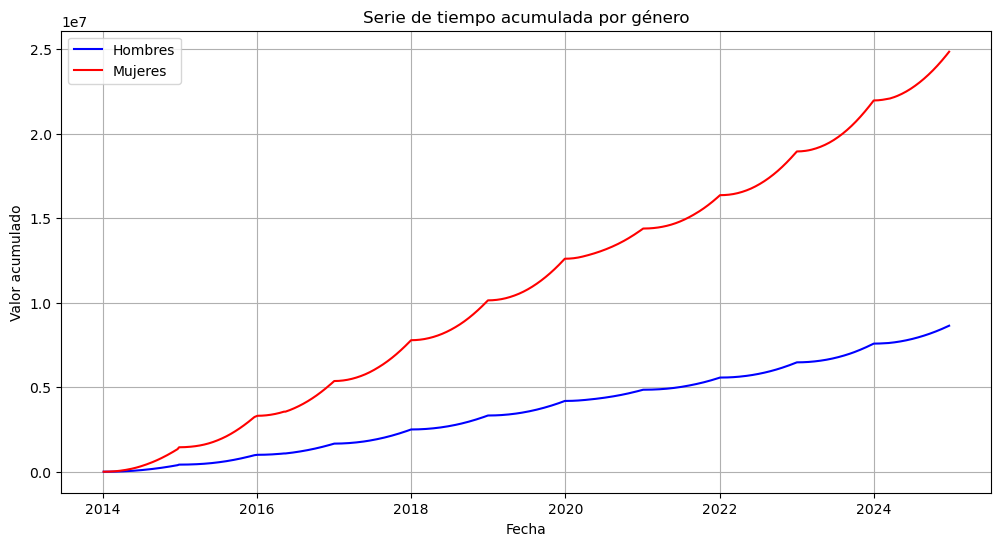

In [50]:
# Gráfica de línea con seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_h_acum, x='Fecha', y='Valor_acumulado', label='Hombres', color='blue')
sns.lineplot(data=df_m_acum, x='Fecha', y='Valor_acumulado', label='Mujeres', color='red')
plt.title('Serie de tiempo acumulada por género')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de línea con plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_h_acum['Fecha'],
    y=df_h_acum['Valor_acumulado'],
    mode='lines+markers',
    name='Hombres',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df_m_acum['Fecha'],
    y=df_m_acum['Valor_acumulado'],
    mode='lines+markers',
    name='Mujeres',
    line=dict(color='red')
))

fig.update_layout(
    title='Serie de tiempo acumulada por género',
    xaxis_title='Fecha',
    yaxis_title='Valor acumulado',
    hovermode='x unified'
)

fig.show()

La gráfica muestra la **Serie de Tiempo Acumulada de Casos de Depresión por Género** desde 2014, revelando una tendencia de crecimiento lineal y constante para ambos grupos. El análisis clave es la **disparidad de género**: las **Mujeres** (línea roja) acumulan una cantidad de casos que es consistentemente **más del doble** que la de los **Hombres** (línea azul) a lo largo de todo el período, lo que indica que, a nivel de registro total, la depresión afecta o se reporta con mucha mayor frecuencia en mujeres.

In [51]:
# Guarda el df_m_acum y df_h_acu, en un archivo .parquet
# df_m_acum.to_parquet('../../data/processed/df_m_acum.parquet', index=False)
# print(f'DataFrame guardado exitosamente con {len(df_m_acum):,} registros')
# print(f'Archivo guardado en: ../../data/processed/df_m_acum.parquet')

# df_h_acum.to_parquet('../../data/processed/df_h_acum.parquet', index=False)
# print(f'DataFrame guardado exitosamente con {len(df_h_acum):,} registros')
# print(f'Archivo guardado en: ../../data/processed/df_h_acum.parquet')

## Análisis por entidad federativa

In [52]:
# Agrupa por Estado y calcula el acumulado (excluyendo 'TOTAL')
df_entidades = df[(df['Ax_003'] == 'Sem.') & (df['Estado'] != 'TOTAL')]
df_entidades_acum = df_entidades.groupby(['Estado', 'Fecha'])['Valor'].sum().reset_index()
df_entidades_acum['Valor_acumulado'] = df_entidades_acum.groupby('Estado')['Valor'].cumsum()

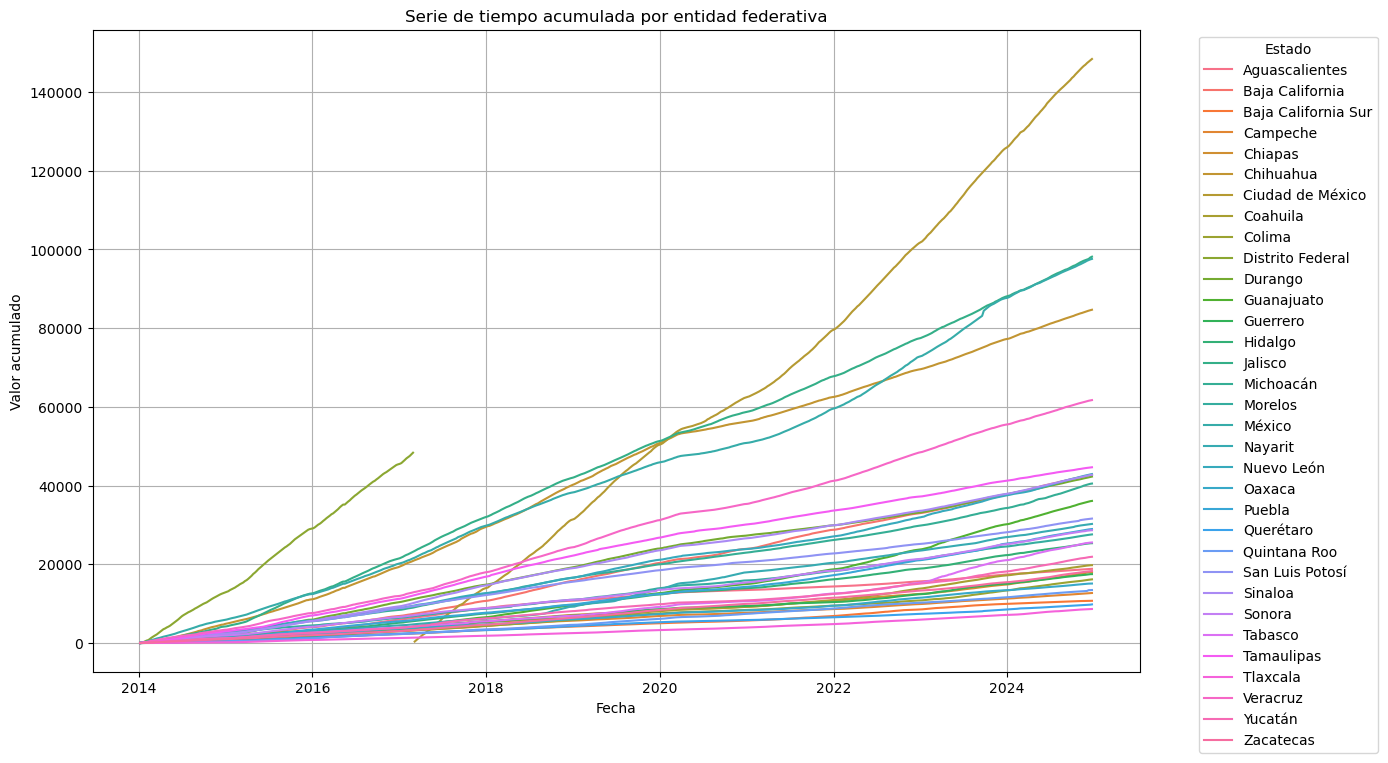

In [53]:
# Gráfica de línea con seaborn
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_entidades_acum,
    x='Fecha',
    y='Valor_acumulado',
    hue='Estado',
    legend='full'
)
plt.title('Serie de tiempo acumulada por entidad federativa')
plt.xlabel('Fecha')
plt.ylabel('Valor acumulado')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfica de línea con plotly
fig = go.Figure()

for estado in df_entidades_acum['Estado'].unique():
    datos_estado = df_entidades_acum[df_entidades_acum['Estado'] == estado]
    fig.add_trace(go.Scatter(
        x=datos_estado['Fecha'],
        y=datos_estado['Valor_acumulado'],
        mode='lines',
        name=estado
    ))

fig.update_layout(
    title='Serie de tiempo acumulada por entidad federativa (sin TOTAL)',
    xaxis_title='Fecha',
    yaxis_title='Valor acumulado',
    hovermode='x unified'
)

fig.show()

In [54]:
# Guarda el df_entidades_acum, en un archivo .parquet
# df_entidades_acum.to_parquet('../../data/processed/df_entidades_acum.parquet', index=False)
# print(f'DataFrame guardado exitosamente con {len(df_entidades_acum):,} registros')
# print(f'Archivo guardado en: ../../data/processed/df_entidades_acum.parquet')

## Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [55]:
ts_data = df_acumulado.set_index('Fecha')['Valor_acumulado_corregido']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data.info()

Serie temporal preparada para descomposición:


Fecha
2014-01-06     131.0
2014-01-13     789.0
2014-01-20    1722.0
2014-01-27    2745.0
2014-02-03    3896.0
Name: Valor_acumulado_corregido, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: Valor_acumulado_corregido
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


Se aplica la descomposición de la serie temporal para separar la tendencia, la estacionalidad y el residuo. Se utiliza la función `seasonal_decompose` de la librería `statsmodels`.

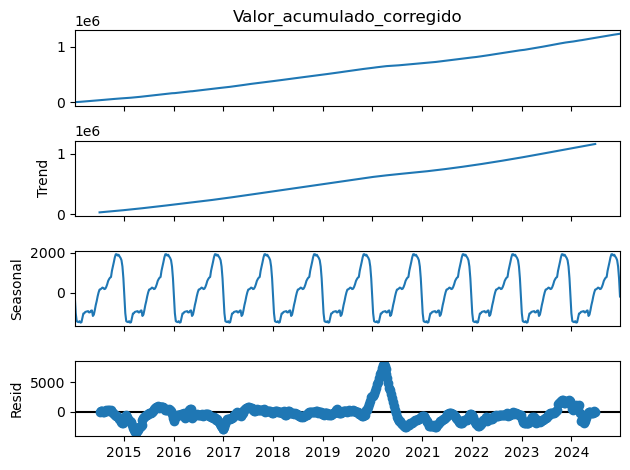

In [56]:
# Aplicar la descomposición aditiva
decomposition = seasonal_decompose(ts_data, model='additive')

# Mostrar los resultados de la descomposición
fig = decomposition.plot()
plt.show()

### **Análisis de la Descomposición de la Serie Acumulada**

**Tendencia (Trend):** Muestra un **crecimiento lineal y casi perfecto** a lo largo de toda la década (2014-2024). Al corregir los valores atípicos de la serie acumulada, se confirma que la fuerza dominante es una **tendencia alcista ininterrumpida**, indicando un aumento constante y predecible del número total de casos.

**Estacionalidad (Seasonal):** Revela un patrón **anual, cíclico y muy bien definido**, con un pico que se repite anualmente (sube y baja) pero que no tiene grandes variaciones en su amplitud. Este patrón confirma la **influencia de los ciclos anuales** (probablemente laborales o estacionales) en el reporte de casos.

**Residuos (Resid):** El ruido es ahora mucho más controlado y disperso alrededor de cero. El pico anómalo de 2020 (probablemente un efecto de la pandemia o un cambio en el reporte) que antes dominaba la gráfica **ha sido tratado y disminuido**, dejando un ruido residual manejable.

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

## Pruebas de estacionaridad

La prueba ADF se usa para evaluar la **estacionariedad** de una serie. La estacionariedad es una propiedad clave que indica que las propiedades estadísticas de la serie (como la media, la varianza y la autocorrelación) son constantes a lo largo del tiempo.

La prueba ADF tiene dos hipótesis principales:

* **Hipótesis Nula ($H_0$):** La serie de tiempo **no es estacionaria** (es decir, tiene una raíz unitaria).
* **Hipótesis Alterna ($H_a$):** La serie de tiempo **es estacionaria**.

Para tomar una decisión, comparamos el **Estadístico ADF** con los **Valores Críticos** y el **Valor p** con un nivel de significancia (comúnmente 0.05 o 5%).


Por otro lado, la prueba de KPSS tiene hipótesis que son opuestas a las de la prueba ADF:

* **Hipótesis Nula ($H_0$):** La serie de tiempo **es estacionaria** (sin raíz unitaria).
* **Hipótesis Alterna ($H_a$):** La serie de tiempo **no es estacionaria** (es decir, tiene una raíz unitaria).

Para tomar una decisión, comparamos el **Estadístico KPSS** con los **Valores Críticos** y el **Valor p** con un nivel de significancia (usualmente 0.05).

Se aplica la prueba de Dickey-Fuller Aumentada (ADF) a la serie temporal `ts_data` para evaluar la presencia de una raíz unitaria.


In [57]:
# Realizar la prueba ADF
adf_test = adfuller(ts_data)

# Imprimir los resultados
print('Resultados de la prueba ADF:')
print(f'Estadístico ADF: {adf_test[0]}')
print(f'Valor p: {adf_test[1]}')
print('Valores críticos:')
for key, value in adf_test[4].items():
    print(f'   {key}: {value}')

Resultados de la prueba ADF:
Estadístico ADF: 3.33815760314214
Valor p: 1.0
Valores críticos:
   1%: -3.4418948967017475
   5%: -2.8666329082535222
   10%: -2.569482366838501


### Análisis de Resultados: Prueba ADF

Los resultados de la Prueba de Dickey-Fuller Aumentada (ADF) confirman que la serie de tiempo es **claramente no estacionaria**.

| Criterio | Valor | Nivel de Significancia (5%) | Decisión |
| :--- | :--- | :--- | :--- |
| **Estadístico ADF** | **$3.338$** | $-2.866$ | **Mayor** que el valor crítico |
| **Valor p** | **$1.0$** | $0.05$ | **Mayor** que el nivel |

Dado que el **Estadístico ADF ($3.338$**) es mucho más grande (menos negativo) que el valor crítico al 5% ($-2.866$), y el **Valor p es $1.0$** (mucho mayor que $0.05$), **no podemos rechazar la hipótesis nula ($H_0$)**. La serie de tiempo **no es estacionaria** y tiene una raíz unitaria. Esto es totalmente coherente con la fuerte tendencia de crecimiento que observamos en los análisis de descomposición y los boxplots. Para modelar esta serie, es indispensable aplicar **diferenciación** para inducir la estacionaridad. 

También se aplica la prueba Kwiatkowski-Phillips-Schmidt-Shin (KPSS) a la serie temporal `ts_data`. Esta prueba evalúa si una serie temporal es estacionaria alrededor de una media o una tendencia.

In [58]:
# Realizar la prueba KPSS
kpss_test = kpss(ts_data, regression='c') # 'c' para evaluar si una serie temporal es estacionaria alrededor de una media

# Imprimir los resultados
print('Resultados de la prueba KPSS:')
print(f'Estadístico KPSS: {kpss_test[0]}')
print(f'Valor p: {kpss_test[1]}')
print('Valores críticos:')
for key, value in kpss_test[3].items():
    print(f'   {key}: {value}')

Resultados de la prueba KPSS:
Estadístico KPSS: 3.4534492805858843
Valor p: 0.01
Valores críticos:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


C:\Users\steph\AppData\Local\Temp\ipykernel_4996\1046098728.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




### Análisis de Resultados: Prueba KPSS

Los resultados de la Prueba de KPSS (Kwiatkowski-Phillips-Schmidt-Shin) son definitivos y complementan los hallazgos de la prueba ADF: la serie es **no estacionaria**.

| Criterio | Valor | Nivel de Significancia (5%) | Decisión |
| :--- | :--- | :--- | :--- |
| **Estadístico KPSS** | **$3.453$** | $0.463$ | **Mayor** que el valor crítico |
| **Valor p** | **$0.01$** | $0.05$ | **Menor** que el nivel |

En la prueba KPSS, la hipótesis nula ($H_0$) es que la serie **es estacionaria**. Para rechazar esta hipótesis (y concluir que no es estacionaria), el Estadístico debe ser mayor que el Valor Crítico, o el Valor p menor que $0.05$.

El **Estadístico KPSS ($3.453$**) es significativamente mayor que todos los valores críticos, incluso el del $1\%$ ($0.739$). Además, el **Valor p ($0.01$**) es menor que $0.05$. Por lo tanto, **rechazamos firmemente la hipótesis nula**.

Ambas pruebas (ADF y KPSS) concluyen que la serie de tiempo **no es estacionaria**. Esto se debe a la poderosa tendencia de crecimiento lineal que se han identificado en las gráficas de descomposición. El siguiente paso obligatorio antes de modelar es aplicar **diferenciación** (por ejemplo, restar el valor actual del valor anterior) para estabilizar la media y eliminar esta tendencia.

## Gráfico de Autocorrelación (ACF)

Un gráfico ACF muestra la correlación de una serie temporal con sus propios valores rezagados. Esto nos ayuda a identificar patrones de estacionalidad y la dependencia de los valores actuales con los valores pasados.

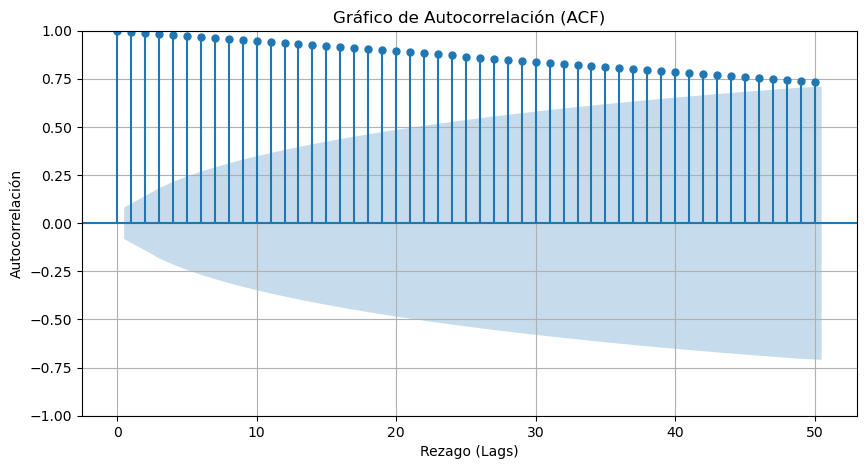

In [59]:
# Crear el gráfico ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ts_data, ax=ax, lags=50)  # Se puede ajustar número
plt.title('Gráfico de Autocorrelación (ACF)')
plt.xlabel('Rezago (Lags)')
plt.ylabel('Autocorrelación')
plt.grid(True)
plt.show()

### **Análisis del Gráfico ACF**

**Decaimiento Lento (Tendencia):** La característica dominante es una **autocorrelación positiva y extremadamente fuerte** que decae muy lentamente, manteniéndose significativa hasta el rezago 50. Este decaimiento lento es el sello distintivo de una **serie no estacionaria con una fuerte tendencia** a largo plazo. Confirma el hallazgo de las pruebas ADF y KPSS de que la serie tiene una raíz unitaria.

**Estacionalidad (Patrones Cíclicos):** No se observan picos o valles claros que se repitan en intervalos fijos (por ejemplo, cada 52 semanas), ya que el efecto de la tendencia es tan abrumador que **enmascara la estacionalidad**. La autocorrelación simplemente sigue la inercia de la tendencia.

**Conclusión:**

El gráfico ACF **confirma la no estacionariedad de la serie** debido a la persistente tendencia de crecimiento. Para utilizar modelos de series de tiempo que requieran estacionariedad, es **obligatorio** aplicar una **diferenciación** de orden 1 (o más) para que la autocorrelación caiga rápidamente a cero. .